In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [2]:
train_dir="Training"
test_dir="Testing"

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 5600 files belonging to 4 classes.


In [4]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [5]:
class_names = train_data.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [6]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

test_data = test_data.map(
    lambda x, y: (normalization_layer(x), y)
)

In [7]:
model = models.Sequential([
    
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.6570 - loss: 0.8301 - val_accuracy: 0.7231 - val_loss: 0.9514
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8170 - loss: 0.4717 - val_accuracy: 0.7625 - val_loss: 0.9344
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.8730 - loss: 0.3295 - val_accuracy: 0.8012 - val_loss: 0.9107
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9038 - loss: 0.2590 - val_accuracy: 0.8275 - val_loss: 0.9663
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9236 - loss: 0.1992 - val_accuracy: 0.8650 - val_loss: 0.8388
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9459 - loss: 0.1577 - val_accuracy: 0.8706 - val_loss: 0.9133
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.9538 - loss: 0.1189 - val_accuracy: 0.8769 - val_loss: 0.9724
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9620 - loss: 0.1084 - val_accu

In [ ]:
model.save("CCN_model.keras")

In [11]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 270ms/step - accuracy: 0.8913 - loss: 1.3369
Test Accuracy: 0.8912500143051147


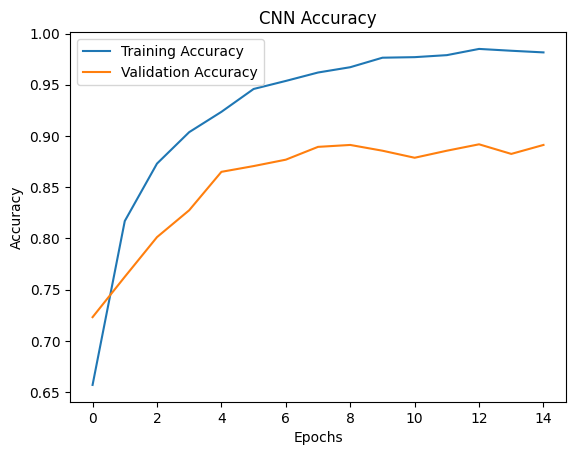

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

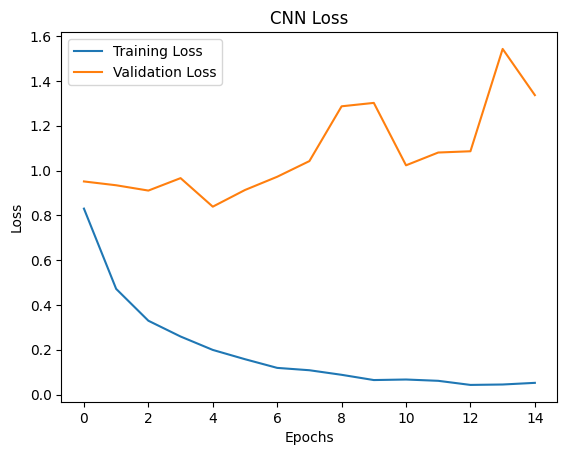

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

In [19]:
y_true = []
y_pred = []

for images, labels in test_data:
    
    predictions = model.predict(images, verbose=0)
    
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [20]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[298  42  51   9]
 [  9 360  22   9]
 [  3   0 397   0]
 [  7  22   0 371]]


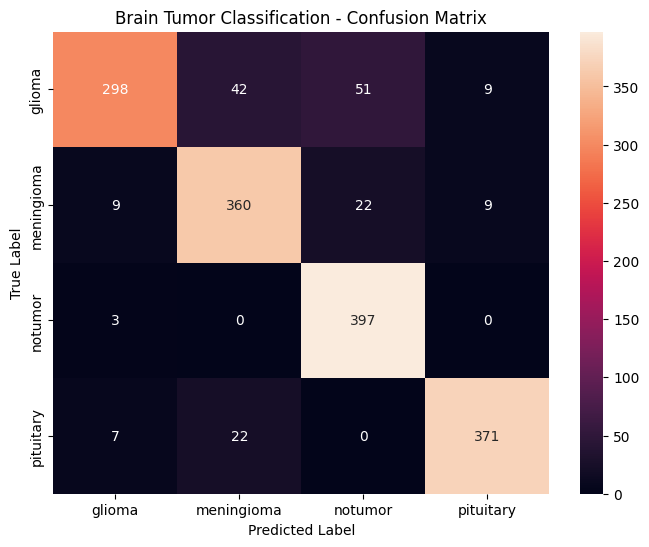

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Brain Tumor Classification - Confusion Matrix")

plt.show()

In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.94      0.74      0.83       400
  meningioma       0.85      0.90      0.87       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.95      0.93      0.94       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600

